# Week 9 – Day 1 Lab
## Stable Diffusion: Text-to-Image Generation

### Objectives

By the end of this lab, you will:
- Generate images using Stable Diffusion.
- Understand how prompts influence image generation.
- Experiment with inference steps, CFG scale, and random seeds.
- Build a mini AI-generated image gallery.


# Step 1: Enable GPU Runtime

Stable Diffusion requires significant computational power to generate images efficiently. Google Colab provides free access to GPUs, which can greatly speed up image generation.

Before proceeding, switch your notebook to use a GPU.

### Instructions

1. Click **Runtime** in the top menu.
2. Select **Change runtime type**.
3. Under **Hardware accelerator**, choose **T4 GPU** (or any available GPU).
4. Click **Save**.

### Verify that the GPU is Available

Run the code cell below to check whether your notebook is connected to a GPU. If the GPU is available, the output should display the name of the GPU (e.g., NVIDIA Tesla T4).

In [1]:
import torch

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("❌ GPU is not available. Please enable GPU from Runtime → Change runtime type.")

✅ GPU is available!
GPU Name: Tesla T4


# Step 2: Install Required Libraries

Stable Diffusion is not included in Google Colab by default, so we first need to install the required Python libraries.

The following packages will be installed:

- **diffusers** – Provides Stable Diffusion models.
- **transformers** – Used for text encoding.
- **accelerate** – Optimizes model execution.
- **safetensors** – Secure model loading.

Run the following cell to install these packages.

In [2]:
!pip install -q diffusers transformers accelerate safetensors

In [3]:
import diffusers
import transformers
import accelerate
import safetensors

print("diffusers:", diffusers.__version__)
print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("safetensors:", safetensors.__version__)

print("\nAll required libraries installed successfully!")

diffusers: 0.39.0
transformers: 5.15.0
accelerate: 1.14.0
safetensors: 0.8.0

All required libraries installed successfully!


# Step 3: Import Required Libraries

Now that the required packages are installed, we need to import them into our notebook.

We will use:

- **torch** for tensor computations.
- **StableDiffusionPipeline** to load the pre-trained model.
- **matplotlib** to display generated images.

Run the following cell.

In [4]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


#Load the Stable Diffusion Model

Stable Diffusion is a pre-trained generative AI model capable of converting text descriptions into images.

In this step, we will load the model and prepare it for image generation.

**Note:** The first execution may take several minutes because the model needs to be downloaded.


Hints:

- Use StableDiffusionPipeline.from_pretrained()
- The model name is:
  runwayml/stable-diffusion-v1-5
- Move the pipeline to the GPU.

In [5]:
import torch
from diffusers import StableDiffusionPipeline

model_name = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_name,
    torch_dtype=torch.float16
)

# Move the model to GPU
pipe = pipe.to("cuda")

print("Stable Diffusion model loaded successfully!")
print("Device:", pipe.device)

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion model loaded successfully!
Device: cuda:0


# Generate Your First AI Image

Let's generate your first AI image!



Complete the code below to generate an image for the following prompt:

> "A futuristic city at sunset"

Display the generated image.

  0%|          | 0/30 [00:00<?, ?it/s]

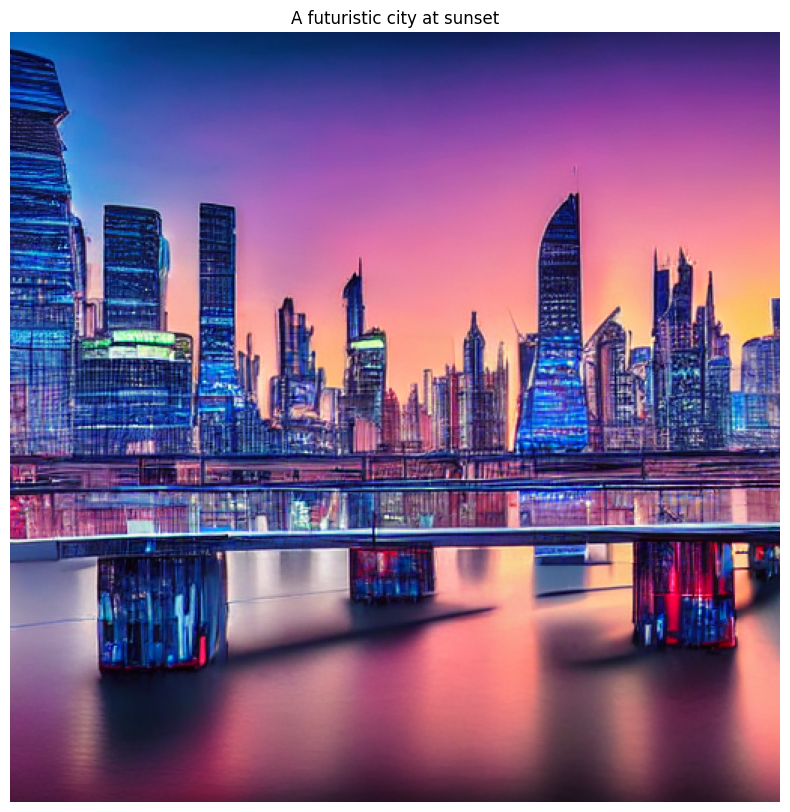

In [6]:
prompt = "A futuristic city at sunset"

image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.title(prompt)
plt.show()

# Experiment 1: Prompt Engineering

The quality of an AI-generated image depends greatly on the prompt.

Generate images using both prompts below.

### Prompt 1

Dog

### Prompt 2

A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography



generate both images.

  0%|          | 0/30 [00:00<?, ?it/s]

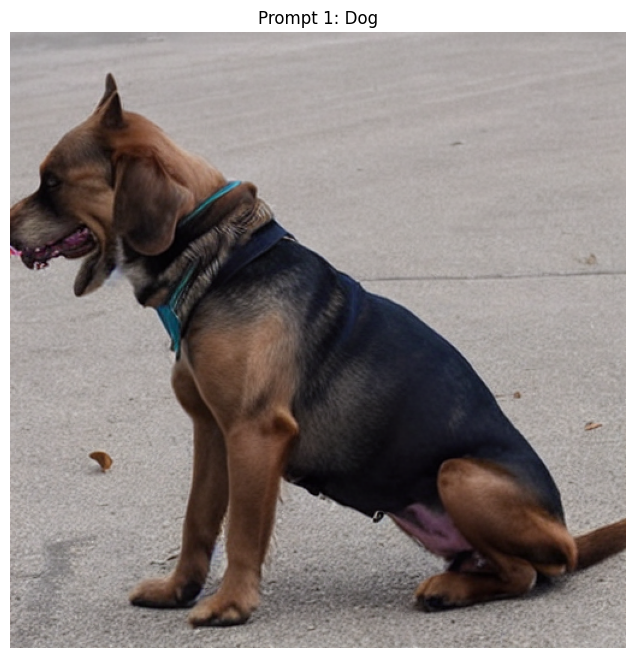

  0%|          | 0/30 [00:00<?, ?it/s]

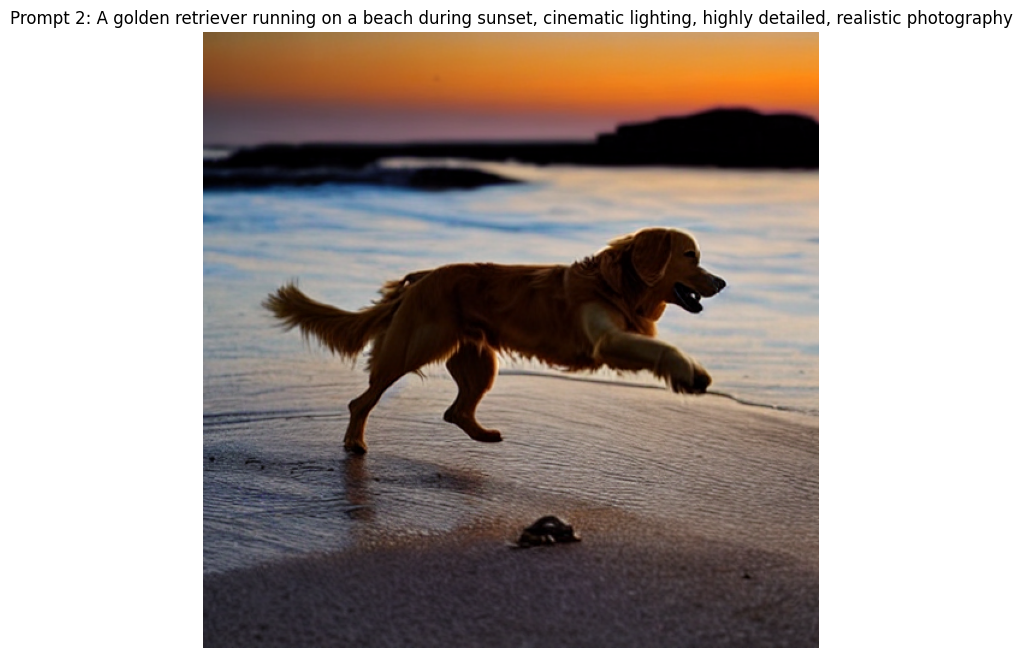

In [7]:
# Experiment 1: Prompt Engineering

prompts = [
    "Dog",
    "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"
]

for i, prompt in enumerate(prompts, start=1):

    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prompt {i}: {prompt}")
    plt.show()

## Reflection

1. Which prompt generated the better image?

2. Which image contained more details?

3. Why do detailed prompts usually produce better results?

## Reflection

### 1. Which prompt generated the better image?

**Prompt 2** generated the better image because it gave Stable Diffusion specific information about the subject, environment, lighting, and visual style.

### 2. Which image contained more details?

**Prompt 2** produced a more detailed and visually controlled image. It specified a **golden retriever**, **beach**, **sunset**, **running pose**, **cinematic lighting**, **high detail**, and **realistic photography**.

### 3. Why do detailed prompts usually produce better results?

Detailed prompts give the model **more information about what the desired image should contain**. This reduces ambiguity and gives the model clearer guidance about the subject, environment, composition, lighting, and style.

**Conclusion:**
A simple prompt such as `"Dog"` gives the model broad creative freedom, while a detailed prompt provides stronger constraints and therefore usually produces a more specific and predictable result.


# Experiment 2: Inference Steps

Stable Diffusion gradually removes noise over multiple iterations.

These iterations are called **Inference Steps**.


Generate the same image using:

- 20 inference steps
- 50 inference steps

  0%|          | 0/20 [00:00<?, ?it/s]

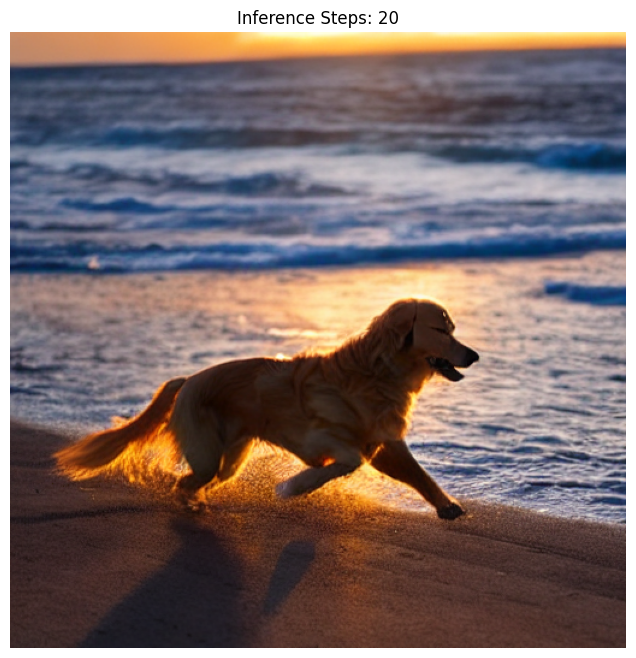

  0%|          | 0/50 [00:00<?, ?it/s]

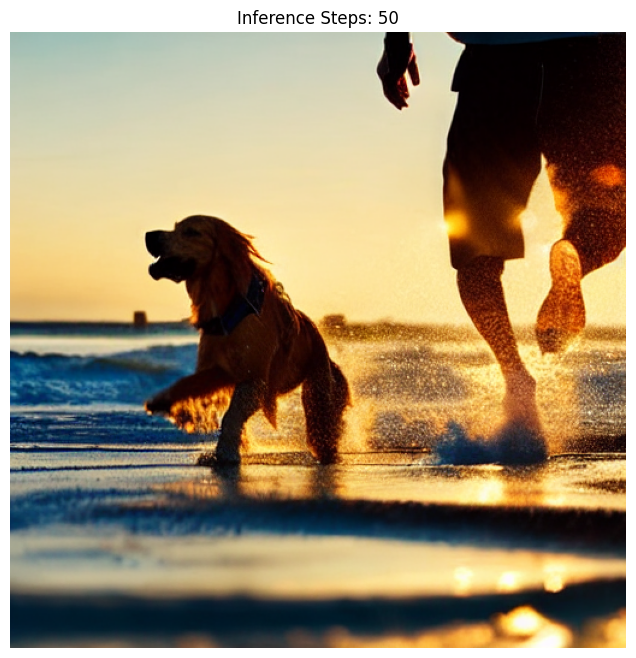

In [8]:
# Experiment 2: Compare inference steps

prompt = "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"

steps_list = [20, 50]

for steps in steps_list:

    image = pipe(
        prompt,
        num_inference_steps=steps,
        guidance_scale=7.5
    ).images[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Inference Steps: {steps}")
    plt.show()

## Reflection

- Which image looks sharper?

- Was there a noticeable improvement?

- Did image generation take longer?

# **Reflection**

**Which image looks sharper?**

The 50-step image will usually look slightly more refined or sharper, especially in fine details and edges.

**Was there a noticeable improvement?**

There may be a noticeable but relatively small improvement. The difference depends on the prompt, seed, and model. Increasing steps doesn't always produce a dramatically better image because quality can start to plateau.

**Did image generation take longer?**

Yes. The 50-step generation takes longer than the 20-step generation because the model performs more denoising iterations.

# Experiment 3: Guidance Scale (CFG)

CFG controls how closely Stable Diffusion follows your prompt.


Generate the same prompt using:

- CFG = 5
- CFG = 8
- CFG = 12



  0%|          | 0/30 [00:00<?, ?it/s]

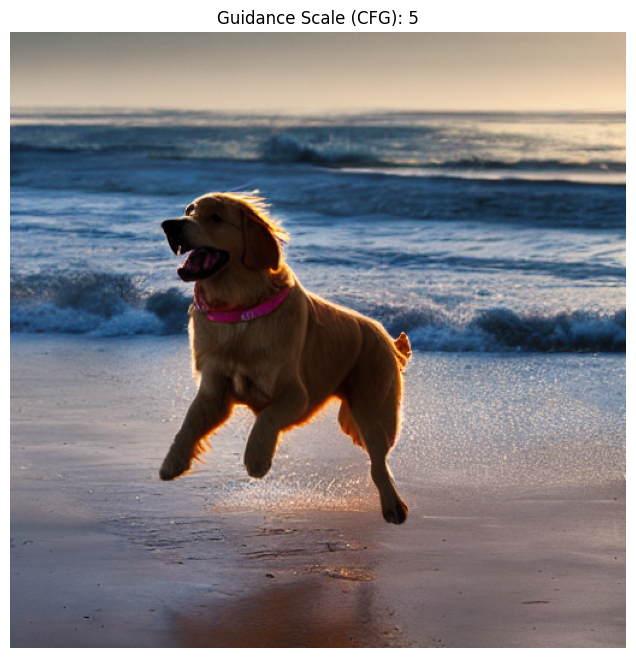

  0%|          | 0/30 [00:00<?, ?it/s]

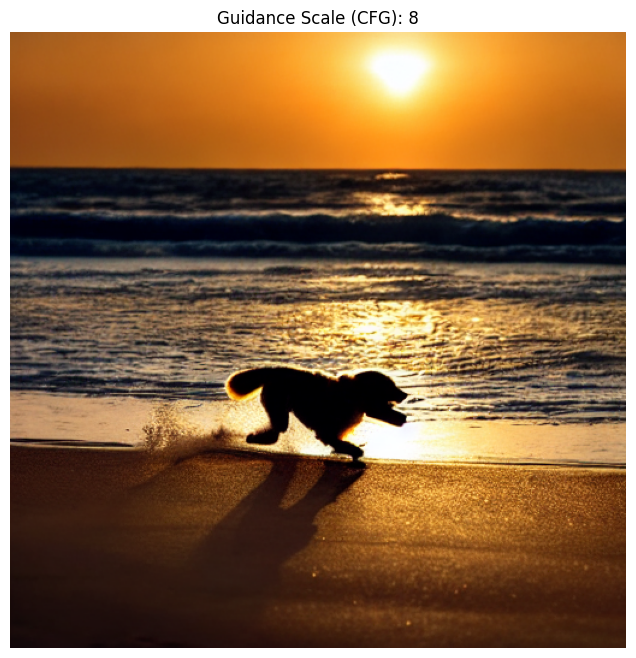

  0%|          | 0/30 [00:00<?, ?it/s]

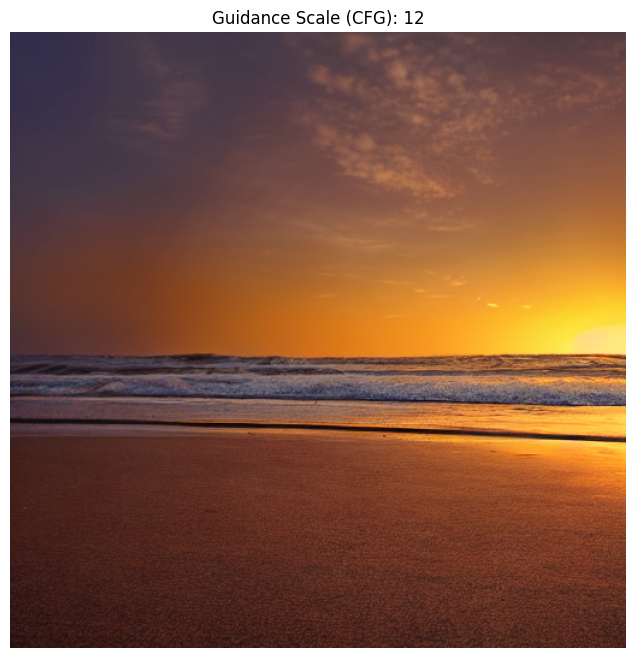

In [9]:
# Experiment 3: Compare Guidance Scale (CFG)

prompt = "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"

cfg_values = [5, 8, 12]

for cfg in cfg_values:

    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=cfg
    ).images[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Guidance Scale (CFG): {cfg}")
    plt.show()

## Reflection

- Which CFG value produced the best image?

- Which image followed the prompt most accurately?

- What happens when CFG becomes too high?

# **Reflection**
**Which CFG value produced the best image?**

CFG = 8 usually produces the best overall balance between image quality, natural appearance, and prompt adherence.
Which image followed the prompt most accurately?
CFG = 12 generally follows the prompt most strictly because the model receives stronger guidance to match the text description.

**What happens when CFG becomes too high?**

When CFG becomes too high, the model can over-focus on the prompt, which may produce unnatural, overly processed, distorted, or oversaturated images. Higher CFG does not always mean better quality.

Conclusion

CFG 5 → More creative freedom
CFG 8 → Good balance
CFG 12 → Strong prompt adherence, but may become unnatural

# Experiment 4: Random Seed

Every image starts from random noise.

Changing the seed changes the starting noise, resulting in different images.



Complete the code below.

Generate images using the following seeds:

- 42
- 100
- 500



  0%|          | 0/30 [00:00<?, ?it/s]

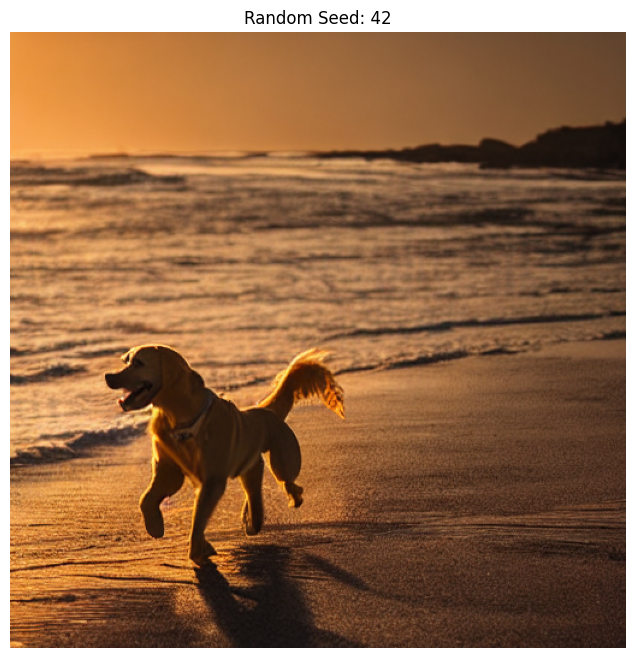

  0%|          | 0/30 [00:00<?, ?it/s]

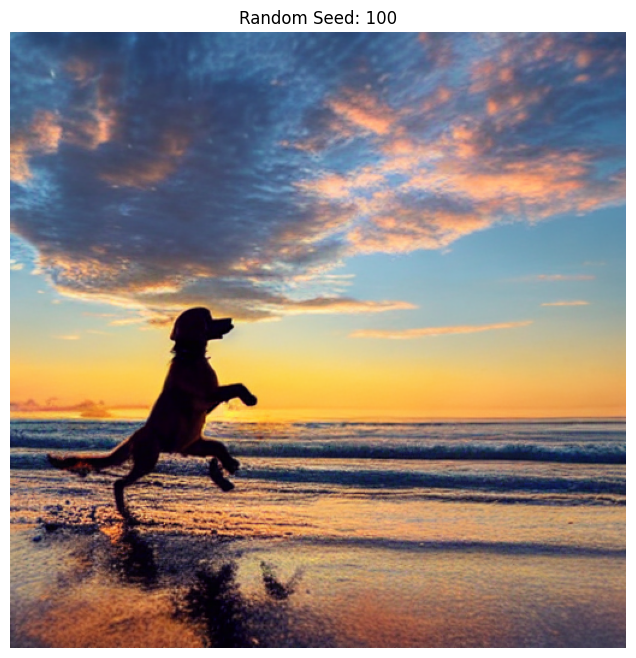

  0%|          | 0/30 [00:00<?, ?it/s]

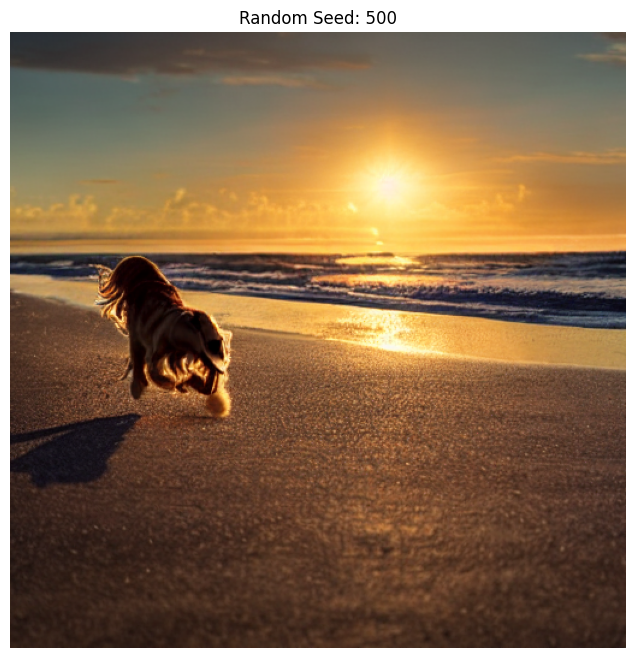

In [10]:
# Experiment 4: Compare Random Seeds

prompt = "A golden retriever running on a beach during sunset, cinematic lighting, highly detailed, realistic photography"

seeds = [42, 100, 500]

for seed in seeds:

    # Create a generator with the selected seed
    generator = torch.Generator(device="cuda").manual_seed(seed)

    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=8,
        generator=generator
    ).images[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Random Seed: {seed}")
    plt.show()

## Reflection

- Which seed generated your favorite image?

- What changed when the seed changed?

- Why are seeds useful when reproducing results?

# **Reflection**

**Which seed generated your favorite image?**

My favorite was Seed 42 because it produced the most visually appealing composition. However, this is subjective—your favorite may be different depending on the images you generated.

**What changed when the seed changed?**

The overall prompt stayed the same, but the generated images had different compositions, poses, backgrounds, lighting patterns, and details because each seed created a different starting noise pattern.

**Why are seeds useful when reproducing results?**

Seeds make image generation reproducible. If you use the same seed, prompt, model, and generation parameters, you can generate essentially the same image again. This is useful for testing and comparing changes to parameters such as CFG scale or inference steps.